In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

# # print("Path to dataset files:", path)

In [3]:
import os 
import time
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import InceptionV3, inception_v3
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

2025-12-14 08:23:27.299570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765700607.727182      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765700607.859600      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [4]:
BASE_PATH = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
train_path = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_path = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

In [5]:
NUM_CLASSES = 38
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
INITIAL_EPOCHS = 10 
FINE_TUNE_EPOCHS = 10 
TOTAL_EPOCHS = INITIAL_EPOCHS + FINE_TUNE_EPOCHS 
TRAIN_PORTION = 0.5
MODEL_ID = "InceptionV3"


In [6]:
print("\nLoading Training Set...")
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path, labels="inferred", label_mode="int", image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, color_mode="rgb", shuffle=True
)

total_batches = training_set.cardinality().numpy()
training_set = training_set.shuffle(buffer_size=100).take(int(total_batches * TRAIN_PORTION))
print(f"Training set loaded, using {int(total_batches * TRAIN_PORTION)} batches ({TRAIN_PORTION*100}%).")


validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path, labels="inferred", label_mode="int", image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, color_mode="rgb", shuffle=True
)

test_set = tf.keras.utils.image_dataset_from_directory(
    valid_path, labels="inferred", label_mode="int", color_mode="rgb",
    batch_size=1, image_size=IMG_SIZE, shuffle=False, 
)
class_name = test_set.class_names


Loading Training Set...
Found 70295 files belonging to 38 classes.


I0000 00:00:1765700661.017943      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765700661.018535      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training set loaded, using 1098 batches (50.0%).
Found 17572 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [7]:
base_inceptionv3 = InceptionV3(
    weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,)
)
base_inceptionv3.trainable = False

inceptionv3_model = tf.keras.models.Sequential([ 
    layers.Input(shape=IMG_SIZE + (3,)), 
    layers.Lambda(inception_v3.preprocess_input), 
    base_inceptionv3,
    layers.GlobalAveragePooling2D(), 
    layers.Dropout(0.4),
    layers.Dense(256, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax") 
])

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
inceptionv3_model.compile(
    optimizer=optimizers.Adam(1e-3), 
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n--- InceptionV3 Model Summary (Feature Extraction) ---")

inceptionv3_model.summary()


--- InceptionV3 Model Summary (Feature Extraction) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,337,094 (85.21 MB)

 Trainable params: 534,310 (2.04 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [9]:
print(f"\nStarting Phase 1 (Feature Extraction) for {INITIAL_EPOCHS} epochs...")
start_time = time.time() 
history_initial = inceptionv3_model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=INITIAL_EPOCHS
)
print("Phase 1 finished.")


Starting Phase 1 (Feature Extraction) for 10 epochs...
Epoch 1/10


I0000 00:00:1765700682.916500     114 service.cc:148] XLA service 0x7aece8016b80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765700682.918387     114 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765700682.918409     114 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765700684.899588     114 cuda_dnn.cc:529] Loaded cuDNN version 90300


   1/1098 ━━━━━━━━━━━━━━━━━━━━ 8:22:26 27s/step - accuracy: 0.0312 - loss: 4.0330

I0000 00:00:1765700695.584699     114 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1098/1098 ━━━━━━━━━━━━━━━━━━━━ 213s 169ms/step - accuracy: 0.6508 - loss: 1.2707 - val_accuracy: 0.8879 - val_loss: 0.3400
Epoch 2/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 185s 166ms/step - accuracy: 0.8661 - loss: 0.4064 - val_accuracy: 0.9215 - val_loss: 0.2420
Epoch 3/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 185s 166ms/step - accuracy: 0.8881 - loss: 0.3373 - val_accuracy: 0.9079 - val_loss: 0.2737
Epoch 4/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 185s 166ms/step - accuracy: 0.8940 - loss: 0.3121 - val_accuracy: 0.9222 - val_loss: 0.2270
Epoch 5/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 185s 166ms/step - accuracy: 0.9003 - loss: 0.2929 - val_accuracy: 0.9341 - val_loss: 0.2016
Epoch 6/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 185s 166ms/step - accuracy: 0.9155 - loss: 0.2478 - val_accuracy: 0.9275 - val_loss: 0.2138
Epoch 7/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 185s 166ms/step - accuracy: 0.9148 - loss: 0.2444 - val_accuracy: 0.9327 - val_loss: 0.2055
Epoch 8/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 185s 166ms/step - accuracy: 0.9

In [10]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
)
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1
)
ft_callbacks = [early_stopping, lr_scheduler]

In [11]:
base_inceptionv3.trainable = True

UNFREEZE_LAYER_INDEX = 170 
for layer in base_inceptionv3.layers[:UNFREEZE_LAYER_INDEX]:
    layer.trainable = False

inceptionv3_model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"\nStarting Phase 2 (Fine-Tuning) for max {FINE_TUNE_EPOCHS} epochs with callbacks and LR 1e-5...")


Starting Phase 2 (Fine-Tuning) for max 10 epochs with callbacks and LR 1e-5...


In [12]:
history_fine_tune = inceptionv3_model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_initial.epoch[-1] + 1,
    callbacks=ft_callbacks
)

end_time = time.time() 
training_time = end_time - start_time
print(f"Training finished. Total time: {training_time:.2f} seconds.")

Epoch 11/20
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 339s 275ms/step - accuracy: 0.7590 - loss: 0.9717 - val_accuracy: 0.9584 - val_loss: 0.1272 - learning_rate: 1.0000e-05
Epoch 12/20
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 295s 266ms/step - accuracy: 0.9414 - loss: 0.1697 - val_accuracy: 0.9700 - val_loss: 0.0884 - learning_rate: 1.0000e-05
Epoch 13/20
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 295s 266ms/step - accuracy: 0.9688 - loss: 0.0946 - val_accuracy: 0.9770 - val_loss: 0.0681 - learning_rate: 1.0000e-05
Epoch 14/20
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 295s 266ms/step - accuracy: 0.9799 - loss: 0.0566 - val_accuracy: 0.9804 - val_loss: 0.0602 - learning_rate: 1.0000e-05
Epoch 15/20
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 295s 266ms/step - accuracy: 0.9883 - loss: 0.0326 - val_accuracy: 0.9823 - val_loss: 0.0541 - learning_rate: 1.0000e-05
Epoch 16/20
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 295s 266ms/step - accuracy: 0.9913 - loss: 0.0252 - val_accuracy: 0.9835 - val_loss: 0.0521 - learning_rate: 1.0000e-05
Epoch 17/20
1098/1098 

In [13]:
MODEL_SAVE_PATH = f"{MODEL_ID.lower()}_plant_disease_model.h5" 
try:
    inceptionv3_model.save(MODEL_SAVE_PATH)
    print(f"\n Model successfully saved as: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"\nError saving model: {e}")


 Model successfully saved as: inceptionv3_plant_disease_model.h5


In [14]:
train_loss, train_acc = inceptionv3_model.evaluate(training_set, verbose=0)
print(f'\nTraining accuracy: {train_acc:.4f}')

val_loss, val_acc = inceptionv3_model.evaluate(validation_set, verbose=0)
print(f'Validation accuracy: {val_acc:.4f}')


Training accuracy: 0.9999
Validation accuracy: 0.9866


In [15]:
y_pred_probs = inceptionv3_model.predict(test_set, verbose=0)
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = true_categories.numpy()
predicted_categories = tf.argmax(y_pred_probs, axis=1).numpy()

report = classification_report(Y_true, predicted_categories, target_names=class_name, output_dict=True)

print("\n--- Classification Report ---")
print(classification_report(Y_true, predicted_categories, target_names=class_name, digits=4))


--- Classification Report ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9940    0.9861    0.9900       504
                                 Apple___Black_rot     1.0000    0.9980    0.9990       497
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000       440
                                   Apple___healthy     0.9843    0.9960    0.9901       502
                               Blueberry___healthy     0.9978    0.9978    0.9978       454
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       421
                 Cherry_(including_sour)___healthy     1.0000    0.9956    0.9978       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9603    0.9439    0.9520       410
                       Corn_(maize)___Common_rust_     1.0000    0.9979    0.9990       477
               Corn_(maize)___Northern_Leaf_Blig

In [16]:
metrics_summary = {
    'Model': MODEL_ID,
    'Accuracy': report['accuracy'],
    'Precision (Wgt Avg)': report['weighted avg']['precision'], 
    'Recall (Wgt Avg)': report['weighted avg']['recall'],
    'F1-Score (Wgt Avg)': report['weighted avg']['f1-score'],
}

In [17]:
df_metrics = pd.DataFrame([metrics_summary])
results_file = 'model_performance_summary.csv'

if not os.path.exists(results_file):
    df_metrics.to_csv(results_file, index=False)
else:
    df_metrics.to_csv(results_file, mode='a', header=False, index=False)
    
print(f"\n Metrics successfully saved/appended to {results_file}")


 Metrics successfully saved/appended to model_performance_summary.csv


In [18]:
history = {
    'accuracy': history_initial.history['accuracy'] + history_fine_tune.history['accuracy'],
    'val_accuracy': history_initial.history['val_accuracy'] + history_fine_tune.history['val_accuracy'],
    'loss': history_initial.history['loss'] + history_fine_tune.history['loss'],
    'val_loss': history_initial.history['val_loss'] + history_fine_tune.history['val_loss'],
}

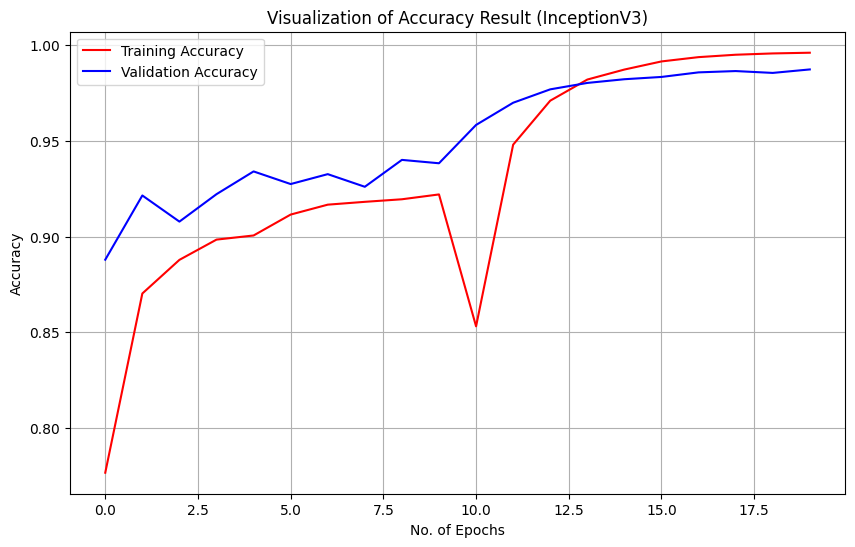

In [19]:
epochs_range = range(len(history['accuracy']))
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs_range, history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.ylabel('Accuracy')
plt.title(f'Visualization of Accuracy Result ({MODEL_ID})')
plt.legend()
plt.grid(True)
plt.show()